# PA1 Part A: Byte Pair Encoding (BPE)

## Overview
In this assignment, you will implement the **Byte Pair Encoding (BPE)** algorithm **from scratch** using Python.  
BPE is a widely used **subword tokenization algorithm** that forms the foundation of tokenizers used in modern language models such as GPT and BERT.

Rather than relying on existing tokenizer libraries, you will build the algorithm step by step to understand:
- How subword vocabularies are learned
- How frequent character patterns are merged
- How unseen or rare words are handled during tokenization

By the end of this assignment, you will have a fully working BPE tokenizer that can be trained on a corpus and applied to new text.

---

## What is Byte Pair Encoding?
Byte Pair Encoding is an **unsupervised, frequency-based tokenization algorithm**.  
It starts with individual characters as tokens and repeatedly merges the **most frequent adjacent token pairs** in the corpus. Over time, this process builds a vocabulary of meaningful subword units.

BPE allows language models to:
- Limit vocabulary size
- Handle rare and unseen words
- Capture common prefixes, suffixes, and roots

---

## Additional Reading
If you would like a more detailed explanation of the algorithm and worked examples, refer to the following resource:

🔗 **GeeksforGeeks – Byte Pair Encoding (BPE) in NLP**  
https://www.geeksforgeeks.org/nlp/byte-pair-encoding-bpe-in-nlp/



<div style="color:red">

## Rules & Constraints

Please read the following rules carefully before starting the assignment.

### ❌ Disallowed
- You **may NOT** use any existing tokenization libraries  
  (e.g., HuggingFace tokenizers, SentencePiece, GPT tokenizers, etc.)
- You **may NOT** use pre-implemented BPE code from external sources

### ✅ Allowed
- Standard Python libraries such as:
  - `collections`
  - `re`
  - `math`
- Pure Python data structures (lists, dictionaries, tuples)

### 📌 Implementation Requirements
- All parts of the **BPE algorithm must be implemented from scratch**
- You must follow the function signatures provided in the notebook
- Your code should be **clear, modular, and well-commented**
- Do **not** modify the provided test cells (if any)

### ⚠️ Academic Integrity
- You must write and submit **your own code**
- Copying implementations from online sources will be considered plagiarism


## Instructions
- <font color="red">Proceed cell by cell and complete all sections where you are asked to write code.</font>
- <font color="red">Carefully read the course outline for the plagiarism policy and late-day rules.</font>
- <font color="red">Run all cells before submitting to receive full credit.</font>
- <font color="red">Do not delete or modify any pre-written code.</font>
- <font color="red">Attempt every part; each section builds toward a complete understanding.</font>
Failure to follow these rules may result in marks deduction.

## Submission Instructions
- <font color="red">Rename the notebook according to you Student ID. For example if you student ID is 27010001, rename the file to 27010001_PART_A</font>
- <font color="red">Once you're done with both Part A and Part B, zip the folder containing both notebooks and rename the folder to your Student ID as well.</font>

</div>


## 1. Dataset: *Alice’s Adventures in Wonderland* [3 Points]

In this assignment, all students will train their Byte Pair Encoding (BPE) tokenizer on the **same fixed corpus**

This text is in the **public domain** and is commonly used in NLP experiments due to its clean language and rich word structure.


### Corpus Details
- Source: *Alice’s Adventures in Wonderland*
- Size: **500 words**
- Preprocessing:
  - Lowercased
  - Punctuation removed
  - Words split on whitespace
- Each word is treated as an **independent unit**



In [2]:
from collections import Counter
import re

# Load the fixed corpus
with open("alice_corpus.txt", "r", encoding="utf-8") as f:
    text = f.read().lower()

# Basic preprocessing
text = re.sub(r"[^a-z\s]", "", text)
words = text.split()

# Count word frequencies
corpus = Counter(words)

print("Number of unique words:", len(corpus))
print("Most common words:", corpus.most_common(10))

Number of unique words: 216
Most common words: [('the', 23), ('to', 21), ('she', 20), ('it', 18), ('of', 15), ('and', 15), ('was', 13), ('a', 13), ('her', 10), ('down', 8)]


In [ ]:
def build_initial_vocab(corpus):
    """
    Build the initial BPE vocabulary from a word-frequency corpus.

    Args:
        corpus (dict): A dictionary mapping words to their frequencies.
                       Example: {"low": 5, "lower": 2}

    Returns:
        vocab (dict): A dictionary mapping space-separated character sequences
                      (with </w> appended) to their frequencies.
    """
    vocab = {}

    # TODO:
    # 1. Iterate over each word and its frequency in the corpus
    # 2. Convert the word into a list of characters
    # 3. Append the end-of-word marker '</w>'
    # 4. Join the symbols with spaces to form the vocabulary key
    # 5. Store the frequency in the vocab dictionary

    for word, freq in corpus.items():
        list_char = list(word) + ['</w>']
        vocab_key = ' '.join(list_char)
        vocab[vocab_key] = freq
    return vocab

In [ ]:
# DO NOT MODIFY THIS CODE, IT IS FOR GRADING.
vocab = build_initial_vocab(corpus)

print("Number of vocabulary entries:", len(vocab))

# Print a few example entries
for i, (k, v) in enumerate(vocab.items()):
    print(f"{k} -> {v}")
    if i == 4:
        break

Number of vocabulary entries: 216
a l i c e </w> -> 7
w a s </w> -> 13
b e g i n n i n g </w> -> 1
t o </w> -> 21
g e t </w> -> 2


## 2. Computing Pair Frequencies [5 Points]

The next step in Byte Pair Encoding (BPE) is to compute the **frequency of adjacent symbol pairs** across the entire vocabulary.

At each iteration of BPE training:
- We identify the **most frequent adjacent pair of symbols**
- This pair will later be merged into a single new symbol

---

### What is a Symbol Pair?

- Given a vocabulary entry like:
- l o w </w>
- The adjacent symbol pairs are:
- (l, o), (o, w), (w, </w>)



If the word occurs with frequency `f`, then **each of these pairs contributes `f`** to the overall pair frequency count.

---

### Why Frequencies Matter

BPE is a **frequency-based greedy algorithm**:
- Pairs that occur most frequently are merged first
- Frequencies must be weighted by word counts in the corpus

Failing to account for frequencies correctly will result in incorrect merge behavior.

---

### Your Task

You will implement a function that:
1. Iterates over all vocabulary entries
2. Extracts adjacent symbol pairs
3. Accumulates their frequencies



In [ ]:
def get_pair_frequencies(vocab):
    """
    Compute frequencies of adjacent symbol pairs in the vocabulary.

    Args:
        vocab (dict): A dictionary mapping space-separated symbol sequences
                      to their frequencies.

    Returns:
        pair_freqs (dict): A dictionary mapping symbol pairs (tuples)
                           to their total frequency.
    """
    pair_freqs = {}

    # TODO:
    # 1. Iterate over each vocabulary entry and its frequency
    # 2. Split the entry into a list of symbols
    # 3. Extract all adjacent symbol pairs
    # 4. Accumulate pair frequencies, weighted by the word frequency

    for vocab_entry,freq in vocab.items():
        list_symbol = vocab_entry.split()
        for i in range(len(list_symbol)-1):
            pair = (list_symbol[i], list_symbol[i+1])
            if pair in pair_freqs:
                pair_freqs[pair] += freq
            else:
                pair_freqs[pair] = freq

    return pair_freqs

In [ ]:
# DO NOT MODIFY THIS CODE, IT IS FOR GRADING.
pair_freqs = get_pair_frequencies(vocab)

# Print the most frequent pairs
sorted_pairs = sorted(pair_freqs.items(), key=lambda x: x[1], reverse=True)

print("Top 10 most frequent symbol pairs:")
for pair, freq in sorted_pairs[:10]:
    print(pair, "->", freq)

Top 10 most frequent symbol pairs:
('e', '</w>') -> 93
('h', 'e') -> 77
('t', '</w>') -> 75
('t', 'h') -> 62
('d', '</w>') -> 47
('e', 'r') -> 45
('s', '</w>') -> 41
('r', '</w>') -> 41
('i', 'n') -> 40
('i', 't') -> 37


## 3. Merging the Most Frequent Pair [5 Points]

Once we have computed the frequencies of all adjacent symbol pairs, the next step in Byte Pair Encoding (BPE) is to **merge the most frequent pair**.

This merge:
- Replaces every occurrence of the selected symbol pair
- Creates a new combined symbol
- Updates the vocabulary accordingly

This operation is applied **globally** across the entire vocabulary.

---

### Example

Suppose the most frequent pair is: ('l', 'o')
- Then the symbols: l o w </w>
- become: lo w </w>

Importantly:
- Only **adjacent** occurrences are merged
- Other symbols remain unchanged
- Frequencies of words remain the same

### Your Task

You will implement a function that:
1. Takes a symbol pair to merge
2. Replaces all occurrences of that pair in the vocabulary
3. Returns an updated vocabulary



In [ ]:
def merge_vocab(pair, vocab):
    """
    Merge all occurrences of a symbol pair in the vocabulary.

    Args:
        pair (tuple): A tuple of two symbols to merge, e.g. ('l', 'o')
        vocab (dict): Current BPE vocabulary mapping symbol sequences
                      to their frequencies.

    Returns:
        new_vocab (dict): Updated vocabulary after merging the pair.
    """
    new_vocab = {}

    # TODO:
    # 1. Iterate over each vocabulary entry and its frequency
    # 2. Split the entry into a list of symbols
    # 3. Scan through the symbols and merge occurrences of the given pair
    # 4. Reconstruct the updated symbol sequence
    # 5. Store it in new_vocab with the same frequency

    for vocab_entry, freq in vocab.items():
        list_symbol = vocab_entry.split()
        new_symbol_seq = []
        i = 0
        while i < len(list_symbol)-1:
            our_pair = (list_symbol[i], list_symbol[i+1])
            if our_pair == pair:
                new_symbol_seq.append(list_symbol[i] + list_symbol[i+1])
                i += 2  
            else:
                new_symbol_seq.append(list_symbol[i])
                i += 1
        if i == len(list_symbol)-1:
            new_symbol_seq.append(list_symbol[-1])
        new_symbol_seq = ' '.join(new_symbol_seq)
        new_vocab[new_symbol_seq] = freq
    return new_vocab

In [ ]:
# DO NOT MODIFY THIS CODE, IT IS FOR GRADING.

# Identify the most frequent pair
pair_freqs = get_pair_frequencies(vocab)
best_pair = max(pair_freqs, key=pair_freqs.get)

print("Most frequent pair:", best_pair)

# Apply merge
vocab = merge_vocab(best_pair, vocab)

# Inspect updated vocabulary
for i, (k, v) in enumerate(vocab.items()):
    print(f"{k} -> {v}")
    if i == 4:
        break


Most frequent pair: ('e', '</w>')
a l i c e</w> -> 7
w a s </w> -> 13
b e g i n n i n g </w> -> 1
t o </w> -> 21
g e t </w> -> 2


## 4. Training the BPE Tokenizer [15 Points]

So far, you have implemented the individual components of Byte Pair Encoding (BPE):
- Initial vocabulary construction
- Pair frequency computation
- Merging a symbol pair

In this section, you will **combine all of these steps** into a full BPE training loop that performs **multiple merge operations**.

This loop is the core of the BPE algorithm.

---

### How BPE Training Works (Recap)

For a fixed number of merge operations:
1. Compute pair frequencies from the current vocabulary
2. Select the **most frequent symbol pair**
3. Merge that pair across the entire vocabulary
4. Record the merge operation
5. Repeat

Each merge introduces a new subword token into the vocabulary.

---

### Your Task

You will implement a function that:
- Trains a BPE tokenizer for a specified number of merges
- Returns both:
  - The final vocabulary
  - The ordered list of merge operations

The **order of merges matters** and must be preserved.

---
Important Notes

If no pairs are available to merge, you may stop early

In case of ties, Python’s default behavior is acceptable

Do not shuffle or reorder merges

In [ ]:

### **TODO: Train BPE **

def train_bpe(corpus, num_merges):
    """
    Train a Byte Pair Encoding (BPE) tokenizer.

    Args:
        corpus (dict): Word-frequency corpus.
        num_merges (int): Number of BPE merge operations to perform.

    Returns:
        vocab (dict): Final BPE vocabulary after all merges.
        merges (list): List of merged symbol pairs, in order.
    """
    # Step 1: Build the initial vocabulary
    vocab = build_initial_vocab(corpus)

    merges = []

    # Step 2: Perform BPE merges
    for i in range(num_merges):
        # TODO:
        # 1. Compute pair frequencies from the current vocabulary
        # 2. Find the most frequent symbol pair
        # 3. Merge that pair in the vocabulary
        # 4. Record the merge operation (append to merges)
        # 5. Update the vocabulary for the next iteration

        pair_freqs = get_pair_frequencies(vocab)
        if not pair_freqs:
            break
        best_pair = max(pair_freqs, key=pair_freqs.get)
        vocab = merge_vocab(best_pair, vocab)
        merges.append(best_pair)
    return vocab, merges

In [ ]:
# DO NOT MODIFY THIS CODE, IT IS FOR GRADING.

toy = {"low": 5, "lower": 2, "newest": 6, "widest": 3}
vocab, merges = train_bpe(toy, num_merges=10)

print("Merges:", merges[:5])
print("Sample vocab:")
for i, (k, v) in enumerate(vocab.items()):
    print(k, "->", v)
    if i == 4:
        break

Merges: [('e', 's'), ('es', 't'), ('est', '</w>'), ('l', 'o'), ('lo', 'w')]
Sample vocab:
low</w> -> 5
low e r </w> -> 2
newest</w> -> 6
wi d est</w> -> 3


## Theoretical Question: Interpreting Early BPE Merges [4 Points]

Using the output of your BPE training:

### Question
Identify **one** of the **first 10 merge operations** learned by your BPE algorithm.

Your answer must include:

1. **The merge operation**  
   - Write the merged token explicitly

2. **Explanation of frequency**  
   - Explain *why* this merge is frequent in the given corpus  

3. **Corpus evidence**  
   - Reference **at least two words** from the corpus in which this merge appears  

### Notes
- You may use intermediate printouts from your code to support your explanation
- Answers that only list the merge without explanation will not receive full credit
- Be concise



Answer:

One of the first 10 merges is (t,h) and the merged token is 'th' from the merge operation ('t','h') -> 'th'

This merge is highly frequent as it appear in the most common word in our corpus "the" appearing '23'. Since BPE algorithm selects the adjacent pair with high frequency so the high repetition of the word "the" makes it possible for (t,h) to be one of the first 10 merges.

The words in which this merge appears are:  
- the
- whether
- think
- nothing
- then
- there

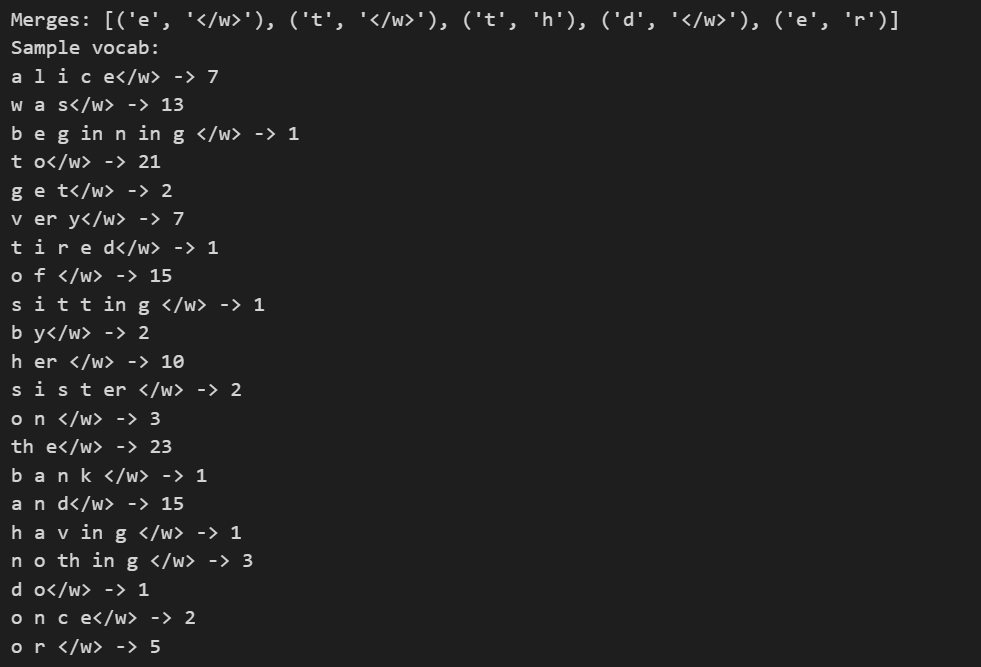

## 5. Tokenizing New Text with Learned BPE Merges [4 Points]

Training BPE produces an **ordered list of merge operations**.  
To tokenize new text, we apply these merges (in order) to each word.

This simulates how BPE tokenizers are used in practice:
- Start with characters + end-of-word marker
- Apply merges sequentially
- Output the resulting subword tokens

---

### Key Idea: Merge Order Matters

If the merge operations are: 
- ('l', 'o') -> 'lo'
- ('lo', 'w') -> 'low'


Then tokenizing `"low"` must apply these merges in the same order to recover:


---

### Your Task

You will implement a function that tokenizes a single word using the learned merge rules.

Steps:
1. Convert the word into a list of characters
2. Append `</w>`
3. For each learned merge pair:
   - Replace all adjacent occurrences of that pair with the merged symbol
4. Return the final list of symbols



In [ ]:
def tokenize_word_bpe(word, merges):
    """
    Tokenize a single word using a learned list of BPE merges.

    Args:
        word (str): Input word (already lowercased, no punctuation).
        merges (list): List of merge operations (tuples), in order.

    Returns:
        tokens (list): List of BPE tokens (symbols) after applying merges.
    """
    # Start from characters
    tokens = list(word) + ["</w>"]

    # TODO:
    # Apply each merge in order.
    # For a given merge pair (a, b), scan through `tokens` left-to-right
    # and merge adjacent occurrences of a followed by b into a single token "ab".
    for merge in merges:
        i=0
        new_tokens = []
        while i<len(tokens)-1:
            our_pair = (tokens[i], tokens[i+1])
            if our_pair == merge:
                new_tokens.append(tokens[i] + tokens[i+1])
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1
        if i == len(tokens)-1:
            new_tokens.append(tokens[-1])
        tokens = new_tokens
    return tokens

In [12]:
# DO NOT MODIFY THIS CODE, IT IS FOR GRADING.

# Train a small BPE model
vocab, merges = train_bpe(corpus, num_merges=50)

test_words = ["alice", "wonderland", "rabbit", "curious", "unseenword"]

for w in test_words:
    print(w, "->", tokenize_word_bpe(w, merges))

# print(merges) -> maybe this will help with the theoratical questions. hmmmm   
# print(merges)

alice -> ['al', 'ic', 'e</w>']
wonderland -> ['w', 'on', 'd', 'er', 'l', 'and</w>']
rabbit -> ['r', 'ab', 'b', 'it</w>']
curious -> ['c', 'ur', 'i', 'ou', 's</w>']
unseenword -> ['u', 'n', 's', 'e', 'en', 'w', 'or', 'd</w>']


## Theoretical Question: Frequent but Linguistically Unintuitive Merges [5 Points]

### Question
Choose **one merge operation** from your learned BPE merges that is frequent but linguistically unintuitive.

Your answer must include:

1. **The merge operation**  
   - Write the merge explicitly

2. **Why BPE learns this merge**  
   - Explain why this merge has high frequency in the corpus  

3. **Impact on tokenization**  
   - State whether this merge **helps or hurts** downstream tokenization. Justify your answer (briefly)

### Notes
- The merge must be taken from your learned merge list
- Focus on reasoning rather than linguistic terminology
- Answers should be grounded in your observed merge statistics



Answer:

The merge that is frequent but linguistically unintuitive is ('e', '< /w >') -> 'e< /w >'.


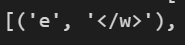

This merge has very high frequency in the corpus because the letter 'e' is the most common ending character for many words in the corpus. In our corpus, many high frequency words like 'the' with frequency '23' and 'she' with frequency '20' and other words like 'alice', 'made' and 'there' all end in 'e'. Due to 'greedy' nature of BPE algorithm it prioritize the most frrequent adjacent pairs regardless of linguistic meaning. The pair ('e', '< /w >') with frequency '93' makes it one of the most statistical choice for a merge.

This merge hurts the downstream tokenization. This merge creates fragmentation across related words.
For example: In the word 'the' the merge might create ('th', 'e< /w >'). However, in the words where 'the' acts as a prefix like 'there' or 'then' the 'e' is not the ending character. This prevents the algorithm from using a consistent 'the' token across all instances. The model makes it harder for a model to recognize the semantic relationship between related terms.


## 6. Tokenizing Full Text with BPE [5 Points]

So far, you have implemented BPE tokenization for a **single word**.  
In practice, tokenizers are applied to **entire texts**, usually by tokenizing each word independently and then concatenating the results.

In this section, you will use your existing `tokenize_word_bpe` function to tokenize a full input string.

---

### Your Task

You will implement a helper function that:
1. Splits the input text on whitespace
2. Applies BPE tokenization to each word
3. Returns a flattened list of BPE tokens

This mirrors how BPE-based tokenizers are typically used in real NLP pipelines.


In [ ]:
def tokenize_text_bpe(text, merges):
    """
    Tokenize a whitespace-separated string using BPE merges.

    Args:
        text (str): Input text (should already be lowercased and cleaned if desired).
        merges (list): Learned BPE merges (tuples), in order.

    Returns:
        tokens (list): Flattened list of BPE tokens for the full text.
    """
    tokens = []

    # TODO:
    # 1. Split the input text into words
    # 2. Tokenize each word using tokenize_word_bpe
    # 3. Append the results to the tokens list

    words = text.split()
    for word in words:
        token = tokenize_word_bpe(word, merges)
        tokens.extend(token)
    return tokens

In [ ]:
# DO NOT MODIFY THIS CODE, IT IS FOR GRADING.
sample = "alice was beginning to get very tired"
# tokens = tokenize_text_bpe(sample.lower(), merges)
tokens = tokenize_text_bpe("there", merges)
print(tokens)

['th', 'er', 'e</w>']
